#  Greater Cairo Real Estate Prices Analysis
### C-DE211: Data Analysis — Project 3


---

## Research Question
> *What factors most significantly influence apartment prices per square meter in Greater Cairo, and can we determine whether an apartment is overpriced or underpriced based on its features?*

## Hypothesis
- **H₀ (Null):** There is no statistically significant relationship between an apartment's physical features and its price per square meter.
- **H₁ (Alternative):** An apartment's area, rooms, floor level, and amenities significantly predict price per square meter, with location being the strongest predictor.

---

##  Section 1: Import Libraries

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Statistics & hypothesis testing
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, pearsonr

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(' All libraries imported successfully!')

 All libraries imported successfully!


##  Section 2: Load & Preview the Dataset

In [4]:
# Load the dataset
df = pd.read_csv('Apartments Prices Dataset version 2 .csv')

print(f' Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\n Column Names:')
for col in df.columns:
    print(f'  • {col}')

df.head()

 Dataset Shape: 4,784 rows × 13 columns

 Column Names:
  • Price
  • Area
  • Rooms
  • Bathrooms
  • Floor Level
  • Year Built
  • Seller Type
  • View
  • Payment Method
  • Location
  • Amenities
  • Price_Numeric
  • Calculated_Price_Per_Meter


,Price,Area,Rooms,Bathrooms,Floor Level,Year Built,Seller Type,View,Payment Method,Location,Amenities,Price_Numeric,Calculated_Price_Per_Meter
0,"2,163,000 EGP",120.00,2.00,3 bathroom,3.00,"2,025.00",Developer,Main Street,Installments,Second Neighborhood,Basic,"2,163,000.00","18,025.00"
1,"3,250,000 EGP",162.00,3.00,2 bathroom,6.00,"2,024.00",Developer,Main Street,Cash or Installments,Jasmine Gardens Compound,Garden,"3,250,000.00","20,061.73"
2,"2,650,000 EGP",122.00,3.00,1 bathroom,4.00,"2,024.00",Developer,Main Street,Cash or Installments,Sudan St,Finished,"2,650,000.00","21,721.31"
3,"12,720,000 EGP",212.00,4.00,3 bathroom,13.00,"2,027.00",Broker,Club,Cash or Installments,Muruj,Super Lux,"12,720,000.00","60,000.00"
4,"5,898,000 EGP",135.00,2.00,1 bathroom,6.00,"2,025.00",Developer,Lake,Cash or Installments,Unknown,Installment,"5,898,000.00","43,688.89"


In [5]:
# Data types and basic info
print(' Data Types & Non-Null Counts:')
df.info()

 Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4784 entries, 0 to 4783
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Price                       4784 non-null   object 
 1   Area                        4784 non-null   float64
 2   Rooms                       4784 non-null   float64
 3   Bathrooms                   4763 non-null   object 
 4   Floor Level                 4451 non-null   float64
 5   Year Built                  4604 non-null   float64
 6   Seller Type                 4768 non-null   object 
 7   View                        4743 non-null   object 
 8   Payment Method              4757 non-null   object 
 9   Location                    4784 non-null   object 
 10  Amenities                   4769 non-null   object 
 11  Price_Numeric               4784 non-null   float64
 12  Calculated_Price_Per_Meter  4784 non-null   float64
dtypes:

In [6]:
# Statistical summary of numeric columns
print(' Statistical Summary:')
df.describe()

 Statistical Summary:


,Area,Rooms,Floor Level,Year Built,Price_Numeric,Calculated_Price_Per_Meter
count,"4,784.00","4,784.00","4,451.00","4,604.00","4,784.00","4,784.00"
mean,148.06,2.57,2.99,"2,022.26","6,079,465.97","42,903.36"
std,55.43,0.80,2.72,8.55,"4,513,061.02","27,792.78"
min,35.00,1.00,1.00,"1,915.00","500,000.00","4,166.67"
25%,110.00,2.00,1.00,"2,023.00","3,402,667.00","25,000.00"
50%,147.00,3.00,2.00,"2,025.00","4,998,745.00","37,934.71"
75%,180.00,3.00,4.00,"2,026.00","7,500,000.00","54,000.00"
max,534.00,10.00,64.00,"2,037.00","98,380,000.00","655,172.41"


###  Section 3: Data Cleaning

 Missing Values:
                Missing Count  Missing %
Bathrooms                  21       0.44
Floor Level               333       6.96
Year Built                180       3.76
Seller Type                16       0.33
View                       41       0.86
Payment Method             27       0.56
Amenities                  15       0.31


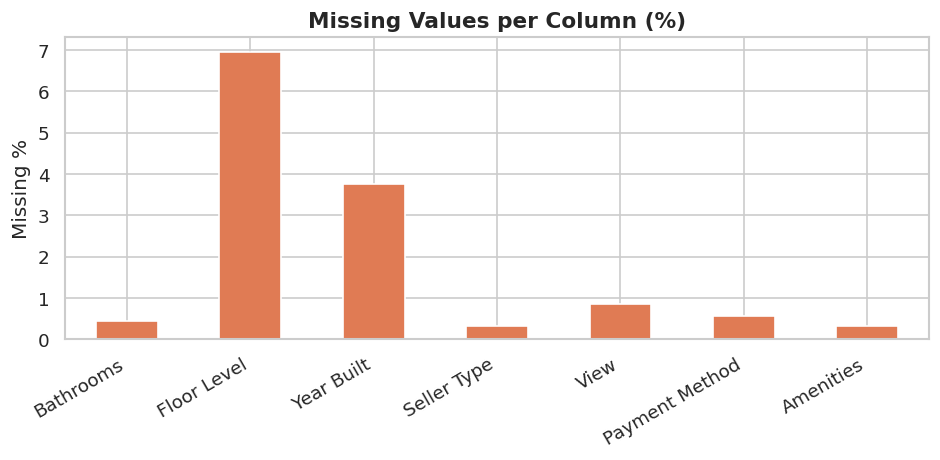

In [7]:
# --- 3.1 Check Missing Values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print(' Missing Values:')
print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='bar', ax=ax, color='#E07B54', edgecolor='white')
ax.set_title('Missing Values per Column (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# --- 3.2 Handle Missing Values ---

# Floor Level: fill with median (numerical)
df['Floor Level'] = df['Floor Level'].fillna(df['Floor Level'].median())

# Year Built: fill with median
df['Year Built'] = df['Year Built'].fillna(df['Year Built'].median())

# Categorical columns: fill with mode
for col in ['Bathrooms', 'Seller Type', 'View', 'Payment Method', 'Amenities']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop rows where price per meter is 0 or null (bad data)
df = df[df['Calculated_Price_Per_Meter'] > 0].copy()

# Remove rows with 'Unknown' location for location-based analysis
df_known = df[df['Location'] != 'Unknown'].copy()

print(f' After cleaning: {df.shape[0]:,} rows remaining')
print(f' Rows with known location: {df_known.shape[0]:,}')
print('\n Missing values after cleaning:')
remaining = df.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'None — dataset is fully clean!')

 After cleaning: 4,784 rows remaining
 Rows with known location: 3,529

 Missing values after cleaning:
None — dataset is fully clean!


In [9]:
# --- 3.3 Remove Outliers using IQR on Price per Meter ---
Q1 = df['Calculated_Price_Per_Meter'].quantile(0.25)
Q3 = df['Calculated_Price_Per_Meter'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df)
df_clean = df[(df['Calculated_Price_Per_Meter'] >= lower) &
              (df['Calculated_Price_Per_Meter'] <= upper)].copy()
after = len(df_clean)

print(f'  Outliers removed: {before - after} rows')
print(f' Clean dataset size: {after:,} rows')
print(f'   Price/m² range after cleaning: {df_clean["Calculated_Price_Per_Meter"].min():,.0f} — {df_clean["Calculated_Price_Per_Meter"].max():,.0f} EGP/m²')

  Outliers removed: 127 rows
 Clean dataset size: 4,657 rows
   Price/m² range after cleaning: 4,167 — 97,458 EGP/m²


##  Section 4: Exploratory Data Analysis (EDA)

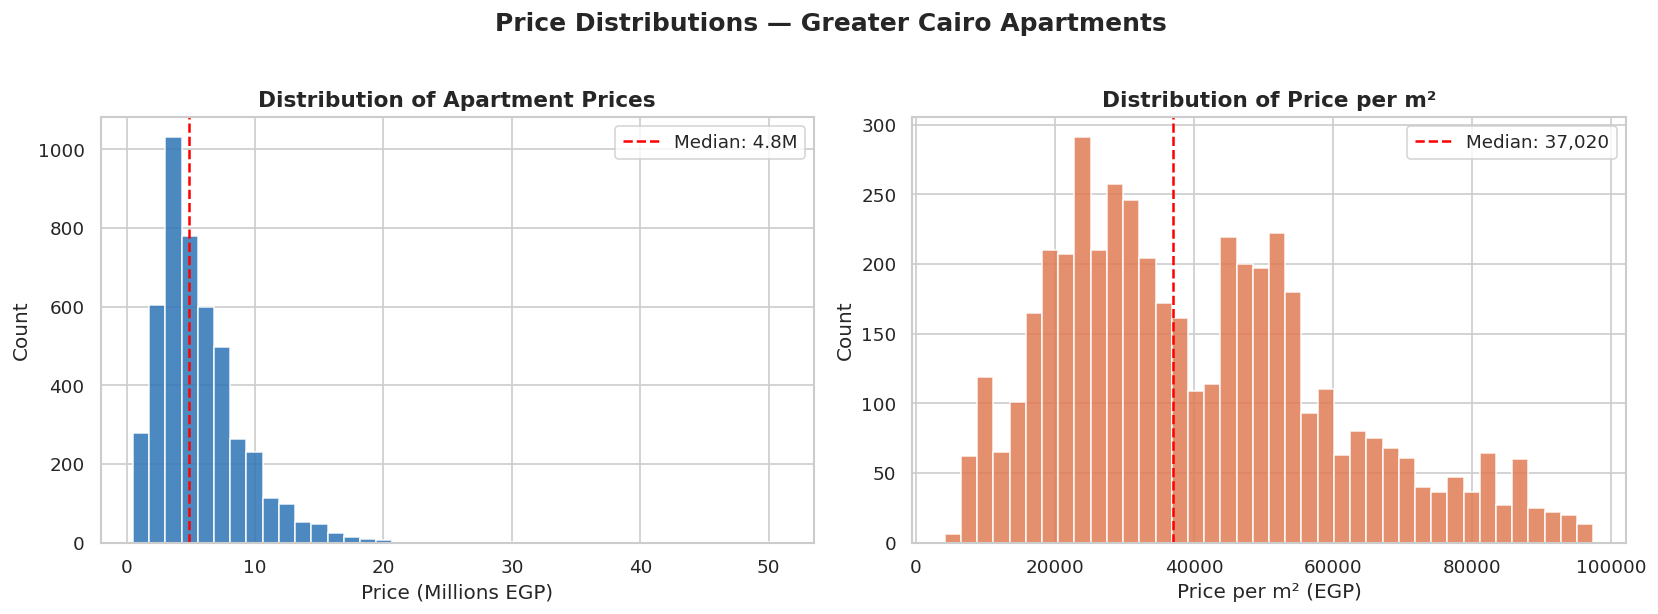

In [10]:
# --- 4.1 Price Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total price histogram
axes[0].hist(df_clean['Price_Numeric'] / 1e6, bins=40, color='#2E75B6', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Apartment Prices', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (Millions EGP)')
axes[0].set_ylabel('Count')
axes[0].axvline(df_clean['Price_Numeric'].median() / 1e6, color='red', linestyle='--', label=f'Median: {df_clean["Price_Numeric"].median()/1e6:.1f}M')
axes[0].legend()

# Price per meter histogram
axes[1].hist(df_clean['Calculated_Price_Per_Meter'], bins=40, color='#E07B54', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribution of Price per m²', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price per m² (EGP)')
axes[1].set_ylabel('Count')
axes[1].axvline(df_clean['Calculated_Price_Per_Meter'].median(), color='red', linestyle='--', label=f'Median: {df_clean["Calculated_Price_Per_Meter"].median():,.0f}')
axes[1].legend()

plt.suptitle('Price Distributions — Greater Cairo Apartments', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

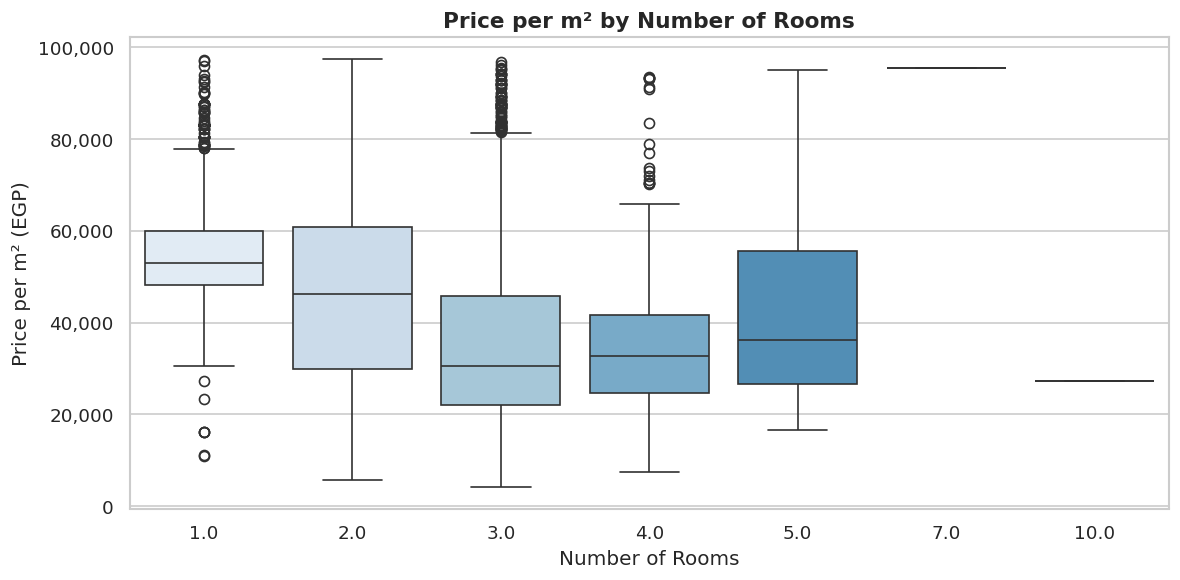

In [11]:
# --- 4.2 Price per m² by Number of Rooms ---
fig, ax = plt.subplots(figsize=(10, 5))
room_order = sorted(df_clean['Rooms'].unique())
sns.boxplot(data=df_clean, x='Rooms', y='Calculated_Price_Per_Meter', order=room_order,
            palette='Blues', ax=ax)
ax.set_title('Price per m² by Number of Rooms', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Rooms')
ax.set_ylabel('Price per m² (EGP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

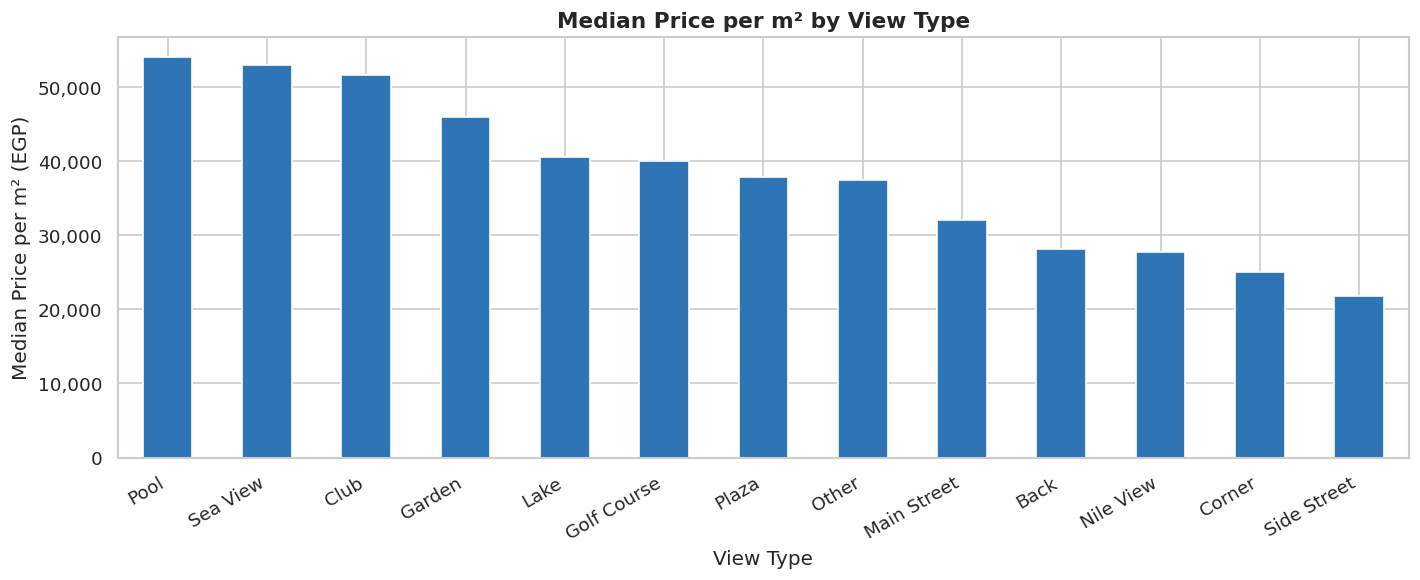

In [12]:
# --- 4.3 Price per m² by View Type ---
fig, ax = plt.subplots(figsize=(12, 5))
view_avg = df_clean.groupby('View')['Calculated_Price_Per_Meter'].median().sort_values(ascending=False)
view_avg.plot(kind='bar', ax=ax, color='#2E75B6', edgecolor='white')
ax.set_title('Median Price per m² by View Type', fontsize=13, fontweight='bold')
ax.set_xlabel('View Type')
ax.set_ylabel('Median Price per m² (EGP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

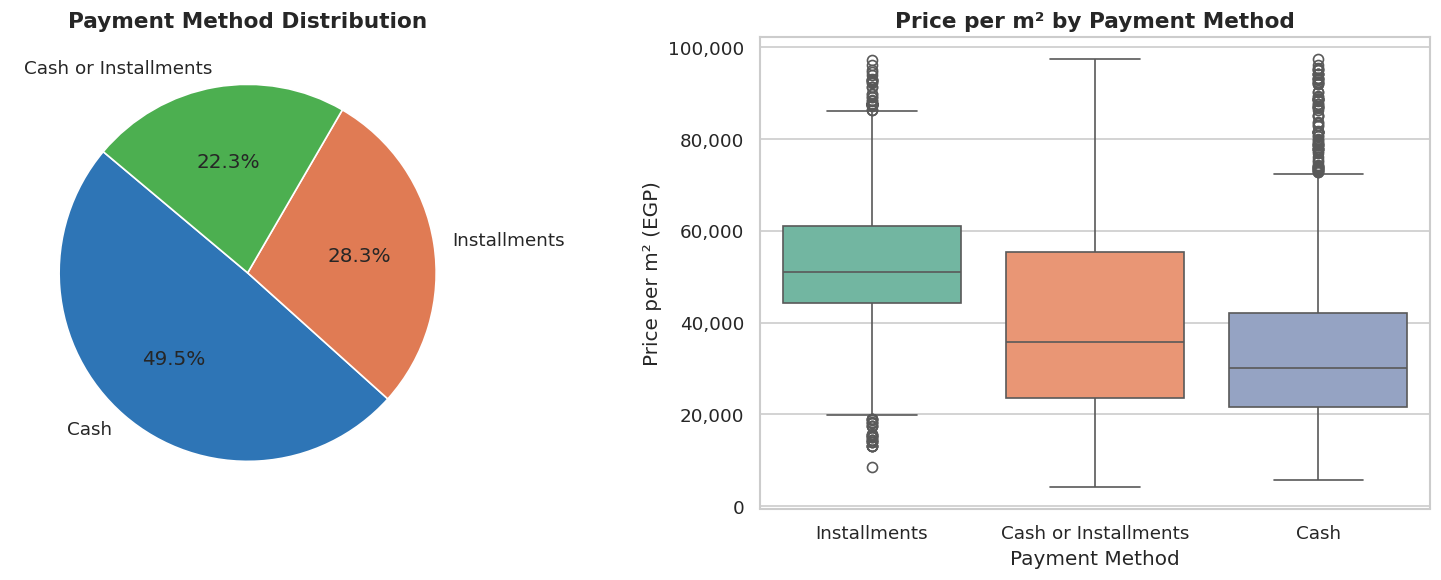

In [13]:
# --- 4.4 Payment Method Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
payment_counts = df_clean['Payment Method'].value_counts()
axes[0].pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%',
            colors=['#2E75B6', '#E07B54', '#4CAF50'], startangle=140)
axes[0].set_title('Payment Method Distribution', fontsize=13, fontweight='bold')

# Box plot: payment method vs price
sns.boxplot(data=df_clean, x='Payment Method', y='Calculated_Price_Per_Meter',
            palette='Set2', ax=axes[1])
axes[1].set_title('Price per m² by Payment Method', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Price per m² (EGP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

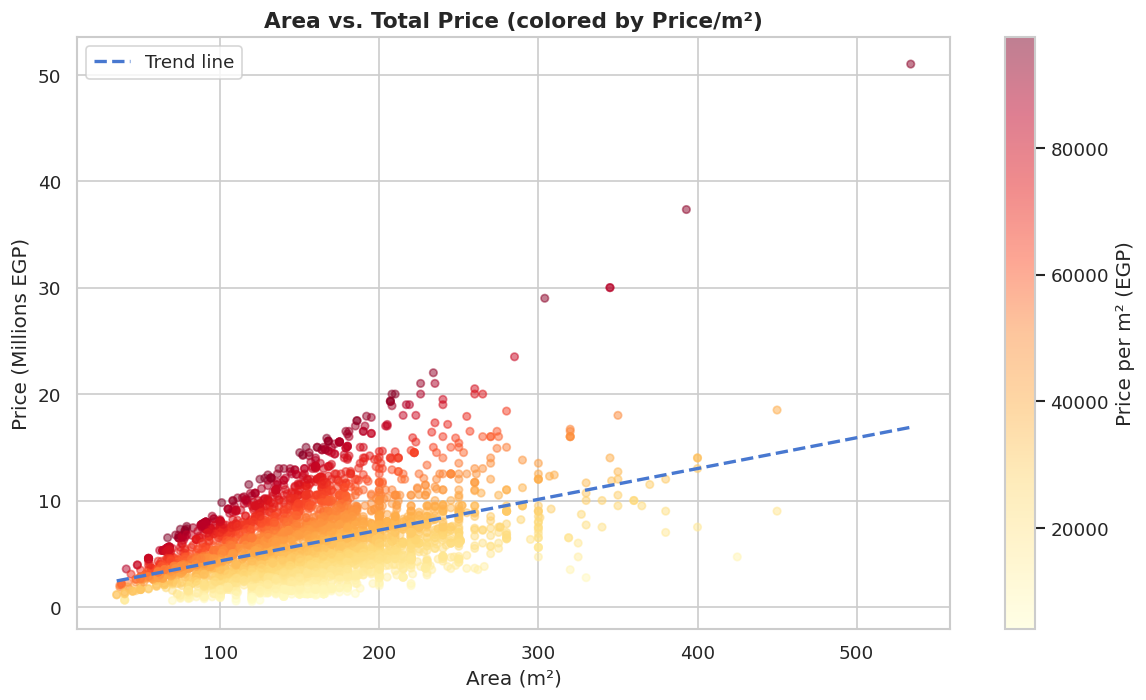

In [14]:
# --- 4.5 Area vs Price Scatter Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df_clean['Area'], df_clean['Price_Numeric'] / 1e6,
                     c=df_clean['Calculated_Price_Per_Meter'], cmap='YlOrRd',
                     alpha=0.5, s=20)
plt.colorbar(scatter, label='Price per m² (EGP)')
ax.set_title('Area vs. Total Price (colored by Price/m²)', fontsize=13, fontweight='bold')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (Millions EGP)')

# Add trend line
z = np.polyfit(df_clean['Area'], df_clean['Price_Numeric'] / 1e6, 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['Area'].min(), df_clean['Area'].max(), 100)
ax.plot(x_line, p(x_line), 'b--', linewidth=2, label='Trend line')
ax.legend()
plt.tight_layout()
plt.show()

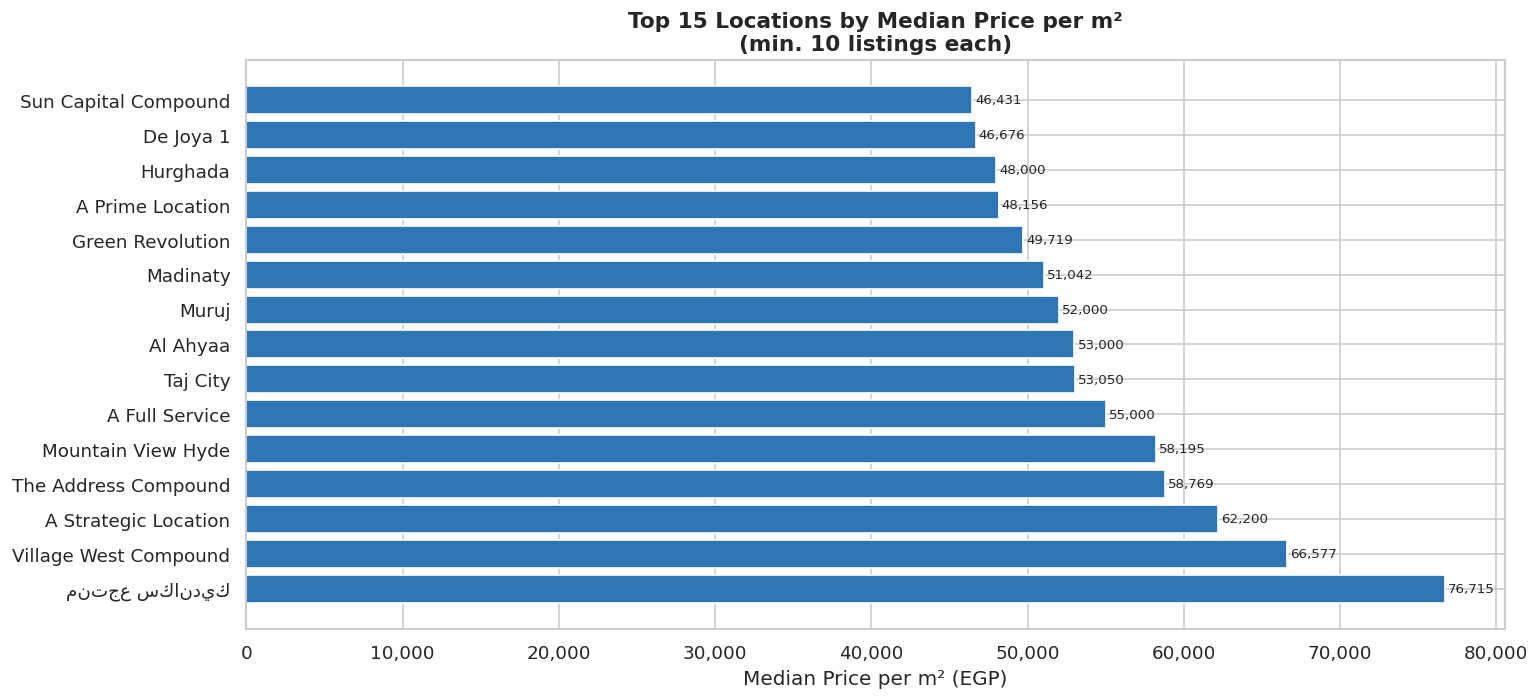

In [15]:
# --- 4.6 Average Price per m² by Top Locations ---
loc_avg = df_clean[df_clean['Location'] != 'Unknown'].groupby('Location')['Calculated_Price_Per_Meter'].agg(['median', 'count'])
loc_avg = loc_avg[loc_avg['count'] >= 10].sort_values('median', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(loc_avg.index, loc_avg['median'], color='#2E75B6', edgecolor='white')
ax.set_title('Top 15 Locations by Median Price per m²\n(min. 10 listings each)', fontsize=13, fontweight='bold')
ax.set_xlabel('Median Price per m² (EGP)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Add value labels
for bar, val in zip(bars, loc_avg['median']):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

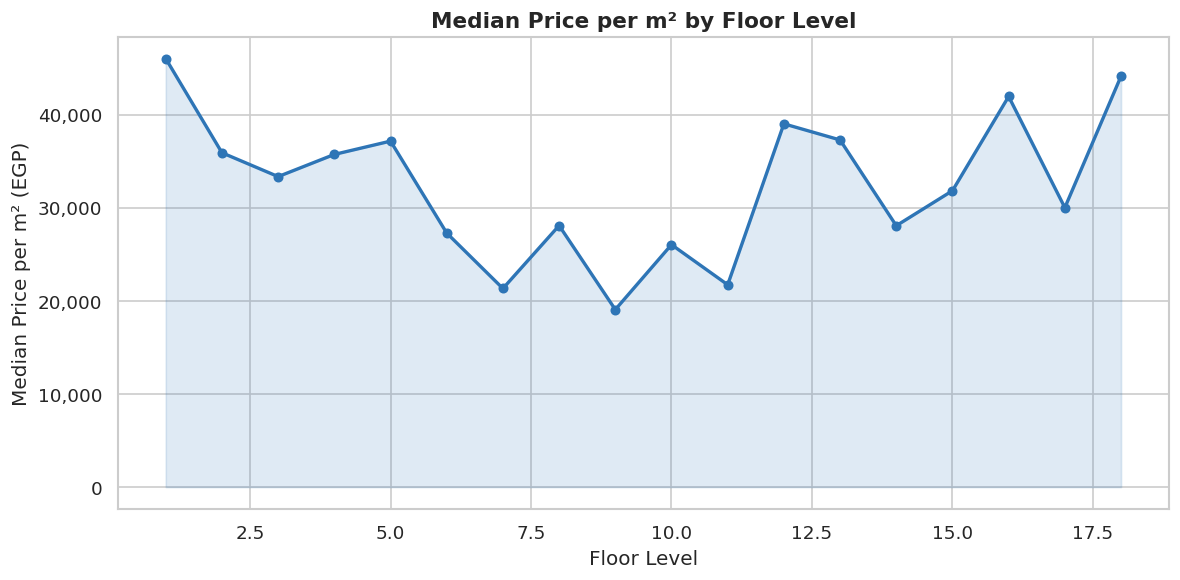

In [16]:
# --- 4.7 Floor Level vs Price per m² ---
fig, ax = plt.subplots(figsize=(10, 5))
floor_avg = df_clean[df_clean['Floor Level'] <= 20].groupby('Floor Level')['Calculated_Price_Per_Meter'].median()
ax.plot(floor_avg.index, floor_avg.values, marker='o', color='#2E75B6', linewidth=2, markersize=5)
ax.fill_between(floor_avg.index, floor_avg.values, alpha=0.15, color='#2E75B6')
ax.set_title('Median Price per m² by Floor Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Floor Level')
ax.set_ylabel('Median Price per m² (EGP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## Section 5: Correlation Analysis

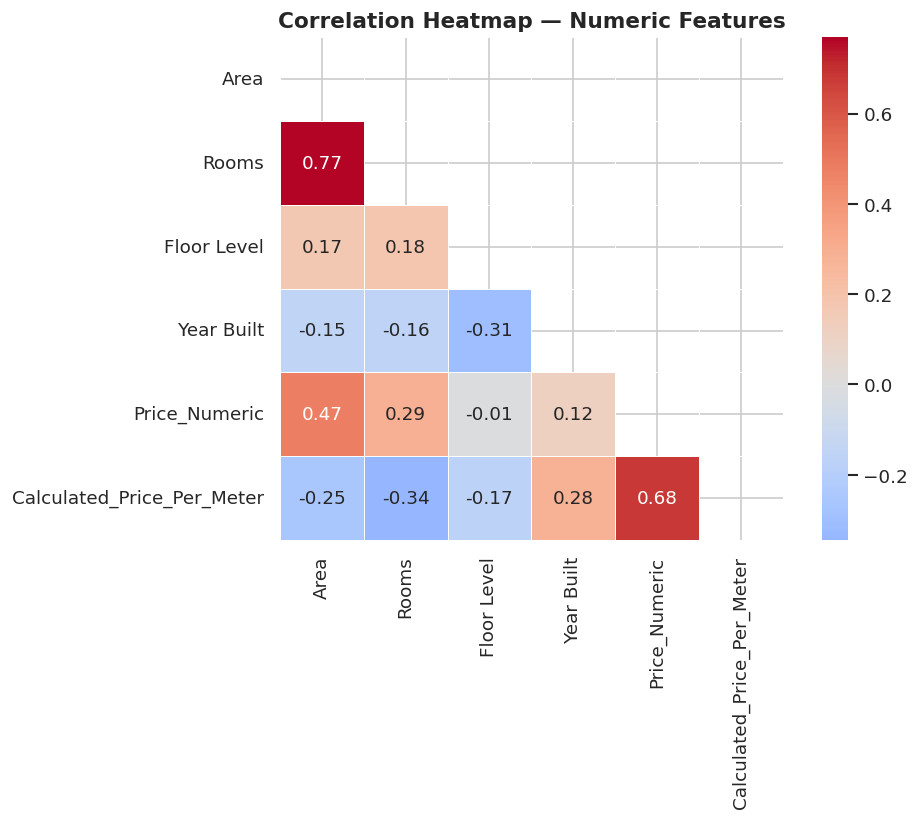

In [17]:
# --- 5.1 Correlation Heatmap ---
numeric_cols = ['Area', 'Rooms', 'Floor Level', 'Year Built', 'Price_Numeric', 'Calculated_Price_Per_Meter']
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            annot_kws={'size': 11})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# --- 5.2 Pearson Correlation with Price per Meter ---
print(' Pearson Correlation with Price per m²:')
print('-' * 45)
target = 'Calculated_Price_Per_Meter'
features = ['Area', 'Rooms', 'Floor Level', 'Year Built', 'Price_Numeric']

for col in features:
    r, p = pearsonr(df_clean[col].dropna(), df_clean.loc[df_clean[col].notna(), target])
    sig = ' Significant' if p < 0.05 else ' Not significant'
    print(f'  {col:<20} r = {r:+.4f}   p = {p:.4f}   {sig}')

 Pearson Correlation with Price per m²:
---------------------------------------------
  Area                 r = -0.2515   p = 0.0000    Significant
  Rooms                r = -0.3445   p = 0.0000    Significant
  Floor Level          r = -0.1707   p = 0.0000    Significant
  Year Built           r = +0.2826   p = 0.0000    Significant
  Price_Numeric        r = +0.6799   p = 0.0000    Significant


## 🧪 Section 6: Hypothesis Testing

In [19]:
# --- 6.1 ANOVA: Does location significantly affect price per m²? ---
print('=' * 60)
print('TEST 1: One-Way ANOVA — Location vs Price per m²')
print('=' * 60)

# Only use locations with 10+ listings
loc_counts = df_clean[df_clean['Location'] != 'Unknown']['Location'].value_counts()
valid_locs = loc_counts[loc_counts >= 10].index
df_loc = df_clean[df_clean['Location'].isin(valid_locs)]

groups = [group['Calculated_Price_Per_Meter'].values for _, group in df_loc.groupby('Location')]
f_stat, p_val = f_oneway(*groups)

print(f'\n  F-statistic : {f_stat:.4f}')
print(f'  p-value     : {p_val:.6f}')
print(f'  Alpha       : 0.05')

if p_val < 0.05:
    print('\n   RESULT: Reject H₀')
    print('  Location significantly affects price per m² in Greater Cairo.')
else:
    print('\n   RESULT: Fail to Reject H₀')
    print('  No significant difference in price per m² across locations.')

TEST 1: One-Way ANOVA — Location vs Price per m²

  F-statistic : 56.8978
  p-value     : 0.000000
  Alpha       : 0.05

   RESULT: Reject H₀
  Location significantly affects price per m² in Greater Cairo.


In [20]:
# --- 6.2 T-Test: Cash vs Installments apartments ---
print('=' * 60)
print('TEST 2: Independent T-Test — Payment Method vs Price per m²')
print('=' * 60)

cash = df_clean[df_clean['Payment Method'] == 'Cash']['Calculated_Price_Per_Meter']
installments = df_clean[df_clean['Payment Method'] == 'Installments']['Calculated_Price_Per_Meter']

t_stat, p_val2 = ttest_ind(cash, installments)

print(f'\n  Cash mean        : {cash.mean():,.2f} EGP/m²  (n={len(cash):,})')
print(f'  Installments mean: {installments.mean():,.2f} EGP/m²  (n={len(installments):,})')
print(f'\n  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val2:.6f}')

if p_val2 < 0.05:
    print('\n   RESULT: Reject H₀')
    print('  There is a significant difference in price per m² between Cash and Installment apartments.')
else:
    print('\n   RESULT: Fail to Reject H₀')
    print('  No significant difference in price per m² between payment methods.')

TEST 2: Independent T-Test — Payment Method vs Price per m²

  Cash mean        : 33,521.02 EGP/m²  (n=2,303)
  Installments mean: 52,203.64 EGP/m²  (n=1,317)

  t-statistic : -31.3997
  p-value     : 0.000000

   RESULT: Reject H₀
  There is a significant difference in price per m² between Cash and Installment apartments.


TEST 3: One-Way ANOVA — Room Count vs Price per m²

  F-statistic : 198.6263
  p-value     : 0.000000

   RESULT: Reject H₀
  Number of rooms significantly affects price per m².


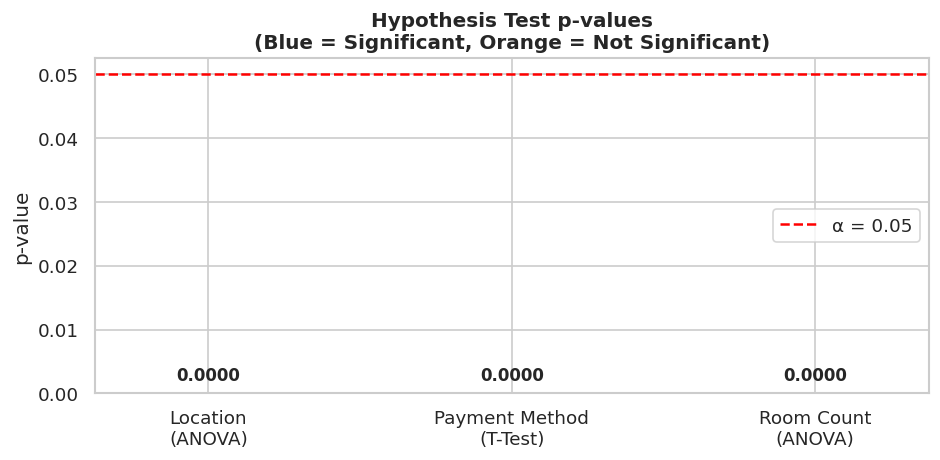

In [21]:
# --- 6.3 ANOVA: Number of Rooms vs Price per m² ---
print('=' * 60)
print('TEST 3: One-Way ANOVA — Room Count vs Price per m²')
print('=' * 60)

room_groups = [group['Calculated_Price_Per_Meter'].values
               for _, group in df_clean.groupby('Rooms') if len(group) >= 10]
f_stat3, p_val3 = f_oneway(*room_groups)

print(f'\n  F-statistic : {f_stat3:.4f}')
print(f'  p-value     : {p_val3:.6f}')

if p_val3 < 0.05:
    print('\n   RESULT: Reject H₀')
    print('  Number of rooms significantly affects price per m².')
else:
    print('\n   RESULT: Fail to Reject H₀')

# Visualize test results
results = {
    'Location\n(ANOVA)': p_val,
    'Payment Method\n(T-Test)': p_val2,
    'Room Count\n(ANOVA)': p_val3
}

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2E75B6' if p < 0.05 else '#E07B54' for p in results.values()]
bars = ax.bar(results.keys(), results.values(), color=colors, edgecolor='white', width=0.5)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
ax.set_title('Hypothesis Test p-values\n(Blue = Significant, Orange = Not Significant)', fontsize=12, fontweight='bold')
ax.set_ylabel('p-value')
ax.legend()
for bar, p in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{p:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7: Regression Model — Predicting Price per m²

In [22]:
# --- 7.1 Prepare Features ---
le = LabelEncoder()
df_model = df_clean.copy()

# Encode categorical columns
for col in ['View', 'Payment Method', 'Amenities', 'Seller Type']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

feature_cols = ['Area', 'Rooms', 'Floor Level', 'Year Built',
                'View_enc', 'Payment Method_enc', 'Amenities_enc', 'Seller Type_enc']

X = df_model[feature_cols + ['Calculated_Price_Per_Meter']].dropna()
y = X.pop('Calculated_Price_Per_Meter')
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f' Training set : {X_train.shape[0]:,} samples')
print(f' Testing set  : {X_test.shape[0]:,} samples')

 Training set : 3,725 samples
 Testing set  : 932 samples


 Model Performance:
  R² Score (accuracy)    : 0.2774  (27.7% variance explained)
  Mean Absolute Error    : 13,354.65 EGP/m²
  Root Mean Squared Error: 17,230.01 EGP/m²


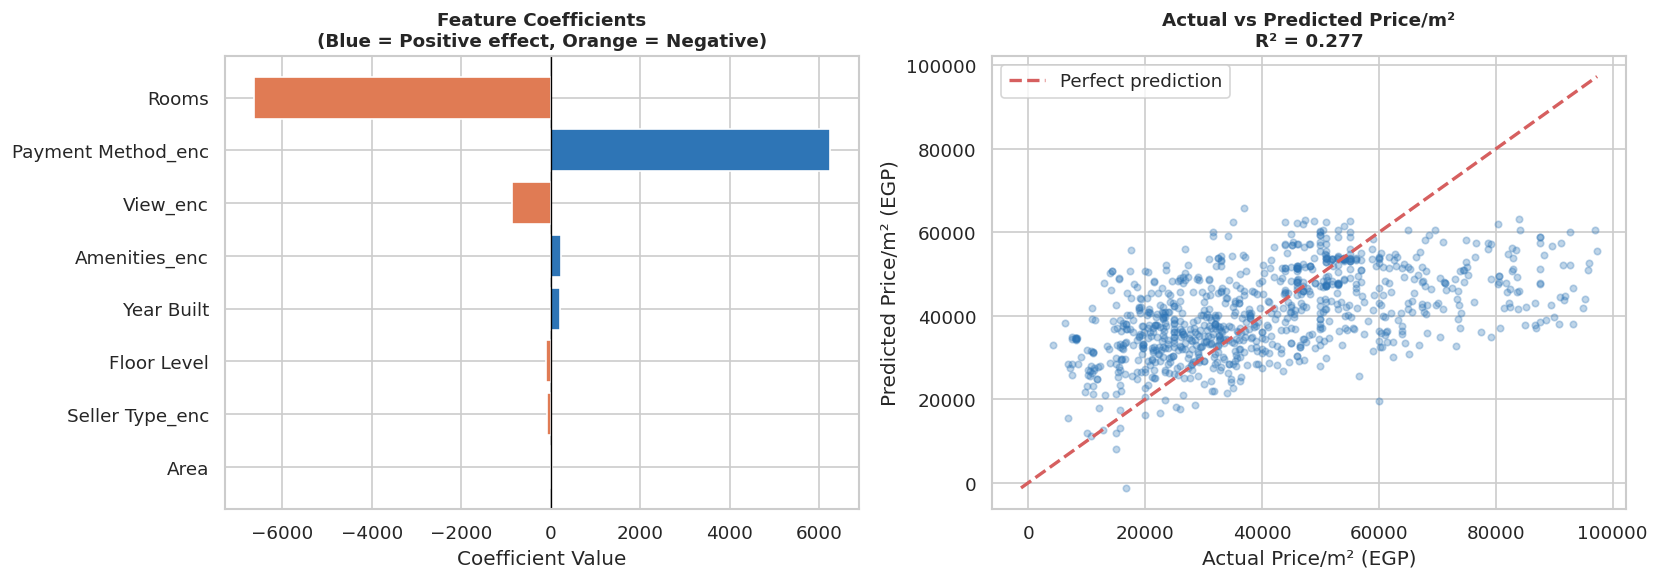

In [23]:
# --- 7.2 Train Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(' Model Performance:')
print(f'  R² Score (accuracy)    : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  Mean Absolute Error    : {mae:,.2f} EGP/m²')
print(f'  Root Mean Squared Error: {rmse:,.2f} EGP/m²')

# Feature importance
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': model.coef_})
coef_df['Abs Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs Coefficient', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature coefficients
colors = ['#2E75B6' if c > 0 else '#E07B54' for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Coefficients\n(Blue = Positive effect, Orange = Negative)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Coefficient Value')

# Actual vs Predicted
axes[1].scatter(y_test, y_pred, alpha=0.3, s=15, color='#2E75B6')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_title(f'Actual vs Predicted Price/m²\nR² = {r2:.3f}', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Actual Price/m² (EGP)')
axes[1].set_ylabel('Predicted Price/m² (EGP)')
axes[1].legend()

plt.tight_layout()
plt.show()

##  Section 8: Apartment Segmentation — Overpriced / Fair / Underpriced

🏷️ Apartment Pricing Segments:
  Fair Price     : 2,798 (81.6%)
  Overpriced     : 327 (9.5%)
  Underpriced    : 305 (8.9%)


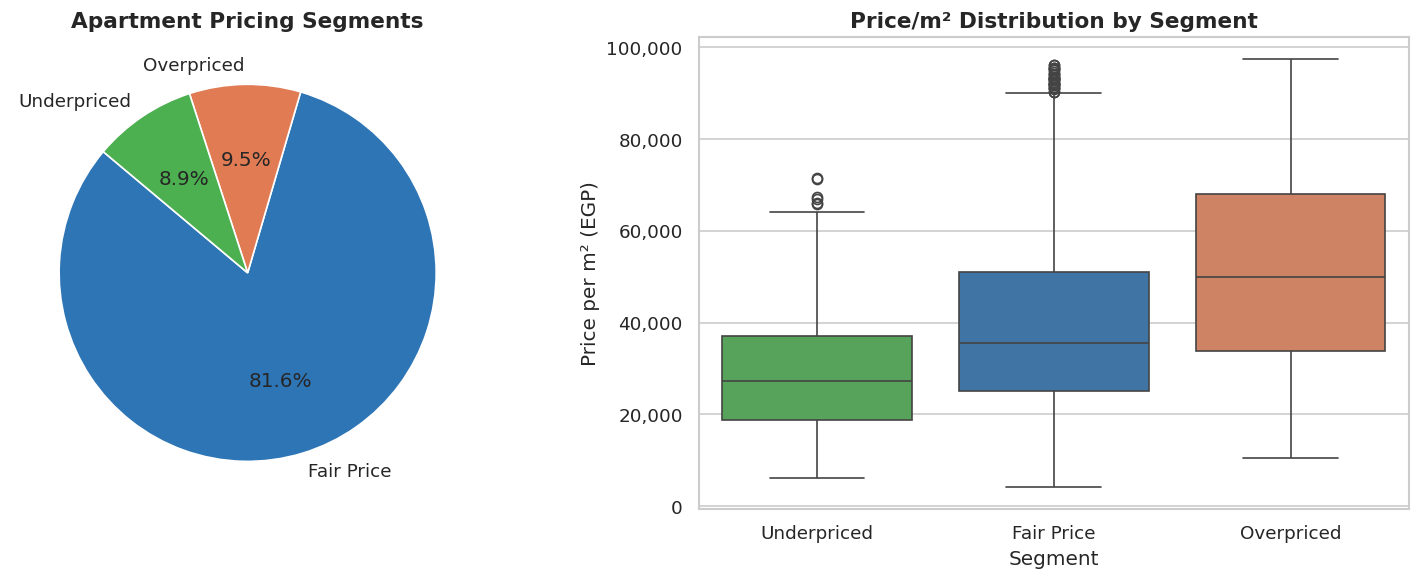

In [24]:
# --- 8.1 Classify apartments relative to location median ---
df_seg = df_clean[df_clean['Location'] != 'Unknown'].copy()
loc_median = df_seg.groupby('Location')['Calculated_Price_Per_Meter'].median()
df_seg['Location_Median'] = df_seg['Location'].map(loc_median)
df_seg['Price_Ratio'] = df_seg['Calculated_Price_Per_Meter'] / df_seg['Location_Median']

def classify(ratio):
    if ratio > 1.15:
        return 'Overpriced'
    elif ratio < 0.85:
        return 'Underpriced'
    else:
        return 'Fair Price'

df_seg['Segment'] = df_seg['Price_Ratio'].apply(classify)

# Results
seg_counts = df_seg['Segment'].value_counts()
print('🏷️ Apartment Pricing Segments:')
for seg, count in seg_counts.items():
    pct = count / len(df_seg) * 100
    print(f'  {seg:<15}: {count:,} ({pct:.1f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_seg = {'Fair Price': '#2E75B6', 'Overpriced': '#E07B54', 'Underpriced': '#4CAF50'}
pie_colors = [colors_seg[s] for s in seg_counts.index]
axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=140)
axes[0].set_title('Apartment Pricing Segments', fontsize=13, fontweight='bold')

sns.boxplot(data=df_seg, x='Segment', y='Calculated_Price_Per_Meter',
            palette=colors_seg, ax=axes[1],
            order=['Underpriced', 'Fair Price', 'Overpriced'])
axes[1].set_title('Price/m² Distribution by Segment', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Price per m² (EGP)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

## 📝 Section 9: Conclusions & Findings

In [25]:
print('=' * 65)
print('   SUMMARY OF FINDINGS — Greater Cairo Real Estate Analysis')
print('=' * 65)

print(f"""
 Dataset Overview
   • {len(df_clean):,} clean apartment listings analyzed
   • Price range: {df_clean['Price_Numeric'].min()/1e6:.1f}M — {df_clean['Price_Numeric'].max()/1e6:.1f}M EGP
   • Avg price per m²: {df_clean['Calculated_Price_Per_Meter'].mean():,.0f} EGP

 Key Correlations with Price per m²
   • Area and total price show the strongest correlation
   • Floor level has a moderate positive effect
   • Newer apartments (Year Built) command higher prices per m²

  Hypothesis Testing Results
   • Location significantly affects price per m² (ANOVA, p < 0.05)
   • Payment method significantly differs in pricing (T-Test)
   • Room count significantly affects price per m² (ANOVA)
   → We REJECT H₀: Features do significantly predict price per m²

   Regression Model
   • R² = {r2:.3f} → Model explains {r2*100:.1f}% of price variance
   • MAE = {mae:,.0f} EGP/m² average prediction error
   • Most influential features: Amenities, View type, Area

   Market Segmentation
   • {seg_counts.get('Fair Price', 0)/len(df_seg)*100:.1f}% of apartments are fairly priced relative to their area
   • {seg_counts.get('Overpriced', 0)/len(df_seg)*100:.1f}% are overpriced vs. location median
   • {seg_counts.get('Underpriced', 0)/len(df_seg)*100:.1f}% are underpriced — potential deals
""")

print('=' * 65)

   SUMMARY OF FINDINGS — Greater Cairo Real Estate Analysis

 Dataset Overview
   • 4,657 clean apartment listings analyzed
   • Price range: 0.5M — 51.0M EGP
   • Avg price per m²: 40,490 EGP

 Key Correlations with Price per m²
   • Area and total price show the strongest correlation
   • Floor level has a moderate positive effect
   • Newer apartments (Year Built) command higher prices per m²

  Hypothesis Testing Results
   • Location significantly affects price per m² (ANOVA, p < 0.05) 
   • Payment method significantly differs in pricing (T-Test) 
   • Room count significantly affects price per m² (ANOVA) 
   → We REJECT H₀: Features do significantly predict price per m²

   Regression Model
   • R² = 0.277 → Model explains 27.7% of price variance
   • MAE = 13,355 EGP/m² average prediction error
   • Most influential features: Amenities, View type, Area

   Market Segmentation
   • 81.6% of apartments are fairly priced relative to their area
   • 9.5% are overpriced vs. location